# Figure 2 - Brownian Motion vs Gradient Descent

This notebook reproduces the Section 4.2 case study on the true-label MNIST classification MDP. The reusable building blocks live in `src/`: the MLP in `src.models.mlp`, the true-label MDP in `src.environments.easy_mdp`, the Hessian ESD estimator (Ghorbani et al.) in `src.pyhessian`, the Brownian-noise step in `src.experiments.brownian_motion`, and the gradient-covariance/KMeans-sorting helpers in `src.experiments.gradient_covariance`. This notebook keeps the run broken into inspectable steps.

In [1]:
import os
from pathlib import Path

import src

ROOT = Path(src.__file__).resolve().parent.parent
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
for directory in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

In [2]:
import copy
import random
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from tqdm import tqdm

from src.environments.easy_mdp import EasyMDP
from src.models.mlp import MLP
from src.agents.replay_buffer import ReplayBuffer

from src.experiments.brownian_motion import brownian_update
from src.experiments.gradient_covariance import (
    compute_gradient_covariance,
    plot_gradient_covariance,
    sort_by_kmeans,
)
from src.pyhessian import Hessian
from src.pyhessian.density_plot import get_esd_plot

In [3]:
seed: int = 42
data_root: str = str(DATA_ROOT)
download: bool = True
hidden_dim: int = 512
gamma: float = 0.99
lr: float = 1e-3
batch_size: int = 512
replay_capacity: int = 10_000
prefill_steps: int = 5_000
target_update_period: int = 5_000
num_target_updates: int = 5  # paper: "after 5 target updates" (Figure 2, Appendix A.1)
train_steps: int = target_update_period * num_target_updates
epsilon: float = 0.1
probe_batch_size: int = 512
cov_batch_size: int = 512
esd_points: int = 600
probe_fit_iters: Tuple[int, ...] = (1, 20)  # paper: covariance at "1 Iteration"/"20 Iterations" of probe optimization

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use mps on mac
# device = torch.device("mps" if torch.backends.mps.is_available() else device)
device

device(type='cpu')

In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(seed)
print(f"Seed set to {seed}")

Seed set to 42


In [6]:
class QNetwork(MLP):
    def __init__(self, hidden_dim: int = 512):
        super().__init__(input_shape=(1, 28, 28), num_actions=10, hidden_dim=hidden_dim)

In [7]:
# load the data and create the environment
transform = transforms.ToTensor()
dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=download,
    transform=transform,
)

In [8]:
env = EasyMDP(dataset, seed=seed)

In [9]:
replay = ReplayBuffer(capacity=replay_capacity)


@torch.no_grad()
def select_action(model: QNetwork, obs: torch.Tensor, epsilon: float) -> int:
    if random.random() < epsilon:
        return random.randrange(10)

    q_values = model(obs.unsqueeze(0).to(device))
    return int(q_values.argmax(dim=1).item())


def collect_transition(
    env: EasyMDP,
    model: QNetwork,
    replay: ReplayBuffer,
    epsilon: float,
) -> None:
    state = int(env.state)
    obs = env.sample_observation(state)
    action = select_action(model, obs, epsilon)
    next_obs, reward, _ = env.step(action)
    replay.push(obs.cpu(), action, reward, next_obs.cpu())


In [10]:
gd_model = QNetwork(hidden_dim).to(device)
bm_model = copy.deepcopy(gd_model).to(device)
target_model = copy.deepcopy(gd_model).to(device)

In [11]:
# print weights and biases of the model
for name, param in gd_model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc1.weight tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
        [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
        [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
        ...,
        [-0.0084, -0.0058,  0.0228,  ...,  0.0293,  0.0206, -0.0119],
        [ 0.0009,  0.0123,  0.0233,  ..., -0.0127, -0.0286,  0.0204],
        [-0.0308,  0.0149, -0.0223,  ...,  0.0130, -0.0236, -0.0194]])
fc1.bias tensor([-1.5505e-02, -3.2696e-02, -1.3353e-02,  3.5505e-02,  1.5904e-02,
         7.8679e-03,  6.5271e-03,  5.7883e-03,  2.8752e-02, -2.1171e-02,
         2.8024e-02,  3.5634e-02,  1.5948e-02,  3.5401e-02,  2.7916e-02,
         3.1786e-02, -1.2170e-02,  2.0021e-02, -4.7394e-03,  1.6366e-02,
        -2.0817e-02, -2.5212e-02,  2.9135e-02, -1.0824e-02, -1.5246e-02,
         1.6319e-02,  3.9158e-03, -2.0049e-02,  6.4671e-06,  9.9425e-03,
        -4.1954e-03,  1.0660e-02, -3.3061e-02, -2.6910e-02,  3.1366e-02,
        -2.7439e-02,  4.0010e-03,  

In [12]:
# prefill the replay buffer
print("Prefilling replay buffer...")
for _ in tqdm(range(prefill_steps)):
    collect_transition(env, gd_model, replay, epsilon)

Prefilling replay buffer...


100%|██████████| 5000/5000 [00:00<00:00, 16487.60it/s]


In [13]:
def make_probe_targets(
    model: QNetwork,
    inputs: torch.Tensor,
    noise: Optional[torch.Tensor] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        if noise is None:
            noise = torch.randn_like(outputs)
        return (outputs + noise).detach(), noise.detach()

In [14]:
def probe_criterion(pred, target):
    return ((pred - target) ** 2).sum() / pred.shape[0]

In [15]:
# plot the hessian esd at initialization, for both trajectories
probe_batch = replay.sample(512)

probe_targets_gd, _ = make_probe_targets(gd_model, probe_batch[0])
hessian_gd = Hessian(
    model=gd_model,
    data=(probe_batch[0], probe_targets_gd),
    criterion=probe_criterion,
    cuda=False,
)
eig_gd, weight_gd = hessian_gd.density(iter=100, n_v=10)

probe_targets_bm, _ = make_probe_targets(bm_model, probe_batch[0])
hessian_bm = Hessian(
    model=bm_model,
    data=(probe_batch[0], probe_targets_bm),
    criterion=probe_criterion,
    cuda=False,
)
eig_bm, weight_bm = hessian_bm.density(iter=100, n_v=10)

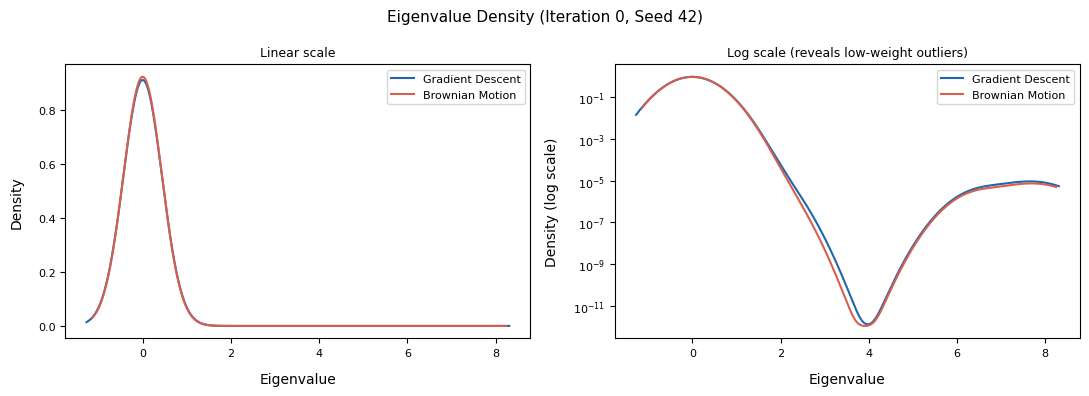

In [16]:
# "iteration" here means number of target updates, matching the paper's Figure 2 labels
# ("Initialization" vs "After 5 target updates"). Colors match the paper: gradient
# descent vs Brownian motion overlaid on the same axes with a legend.
get_esd_plot(
    [
        (eig_gd, weight_gd, "Gradient Descent", "#2166ac"),
        (eig_bm, weight_bm, "Brownian Motion", "#d6604d"),
    ],
    0, seed, out_dir=str(FIGURES_DIR / "esd"),
)

## Sanity Check the Shared Components

Before running the long loop, instantiate the shared MLP and true-label MDP, then step the environment once.

## Run the Experiment

The run couples two trajectories from the same initialization: one follows SGD on the Q-learning objective, and the other receives Brownian parameter perturbations with the same update norm.

In [17]:
optimizer = torch.optim.SGD(gd_model.parameters(), lr=lr)

In [18]:
def q_learning_loss(
    model: QNetwork,
    target_model: QNetwork,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
) -> torch.Tensor:
    states, actions, rewards, next_states = batch
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)

    q_sa = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        td_target = rewards + gamma * next_q

    return F.mse_loss(q_sa, td_target)

In [19]:
def sgd_step_and_update_norm(
    model: QNetwork,
    target_model: QNetwork,
    optimizer: torch.optim.Optimizer,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
    lr: float,
) -> Tuple[float, float]:
    model.train()
    loss = q_learning_loss(model, target_model, batch, gamma)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    update_norm_sq = torch.zeros((), device=device)
    for p in model.parameters():
        if p.grad is not None:
            update_norm_sq += (lr * p.grad).pow(2).sum()

    optimizer.step()
    return float(loss.detach().cpu().item()), float(update_norm_sq.sqrt().cpu().item())

In [20]:
@torch.no_grad()
def evaluate_policy(
    model: QNetwork,
    env: EasyMDP,
    num_samples: int = 1024,
) -> float:
    model.eval()
    correct = 0

    for _ in range(num_samples):
        state = random.randrange(10)
        obs = env.sample_observation(state)
        pred = model(obs.unsqueeze(0).to(device)).argmax(dim=1).item()
        correct += int(pred == state)

    return correct / float(num_samples)

In [21]:
for step in tqdm(range(1, train_steps + 1)):

    collect_transition(env, gd_model, replay, epsilon=epsilon)

    batch = replay.sample(batch_size)
    loss, update_norm = sgd_step_and_update_norm(
        gd_model,
        target_model,
        optimizer,
        batch,
        gamma,
        lr,
    )
    brownian_update(bm_model, update_norm)

    if step % target_update_period == 0:
        # save a snapshot of the current model parameters to the checkpoint directory
        torch.save(gd_model.state_dict(), CHECKPOINTS_DIR / f"hessian_step_{step}.pt")
        target_model.load_state_dict(gd_model.state_dict())
        target_update = step // target_update_period
        accuracy = evaluate_policy(gd_model, env, num_samples=1024)
        log_row = {
            "step": float(step),
            "target_update": float(target_update),
            "loss": float(loss),
            "update_norm": float(update_norm),
            "accuracy": float(accuracy),
        }
        print(
            "target update "
            f"{int(log_row['target_update'])}: "
            f"step={step}, loss={loss:.4f}, "
            f"update_norm={update_norm:.5f}, accuracy={accuracy:.3f}"
        )

 20%|██        | 5020/25000 [00:46<03:24, 97.70it/s] 

target update 1: step=5000, loss=0.0723, update_norm=0.00015, accuracy=0.216


 40%|████      | 10009/25000 [01:35<03:05, 80.64it/s]

target update 2: step=10000, loss=0.1003, update_norm=0.00018, accuracy=0.283


 60%|██████    | 15009/25000 [02:32<02:07, 78.33it/s]

target update 3: step=15000, loss=0.1324, update_norm=0.00015, accuracy=0.335


 80%|████████  | 20017/25000 [03:28<01:01, 81.19it/s]

target update 4: step=20000, loss=0.1853, update_norm=0.00023, accuracy=0.383


100%|██████████| 25000/25000 [04:24<00:00, 94.57it/s]

target update 5: step=25000, loss=0.2029, update_norm=0.00035, accuracy=0.448


## Reading the ESD Plots

`get_esd_plot` overlays both trajectories on the same axes with a legend, matching the paper: **Gradient Descent** vs **Brownian Motion**, each evaluated on its own random-target probe loss. It renders two panels. The **left (linear)** panel matches how Lyle et al. present Figure 2. The **right (log-scale)** panel is Ghorbani et al.'s own convention, included here because it matters for this specific reproduction: the outlier eigenvalue that develops after training carries a tiny fraction of the total SLQ weight (well under 0.1% in practice for this toy MLP/MDP), so it is mathematically invisible as a bump on a linear axis no matter how the smoothing kernel is tuned — it only shows up once density is put on a log scale. The paper doesn't state the exact architecture used for this experiment (Appendix A.1 gives optimizer/batch/target-period for Figure 2 but not width/depth), and a width sweep from 64 to 2048 didn't change this qualitative picture, so this looks like a genuine property of this reproduction's scale rather than a bug or a tunable hyperparameter.

**Why the Hessian is snapshotted at training-time milestones while the gradient covariance (below) is snapshotted along probe-fitting iterations.** The paper's top panels are labeled "Initialization"/"After 5 target updates" — the ESD is a property of a *point* in parameter space, fully visible at the probe-loss construction point. The covariance is a property of the probe-fitting *trajectory* (see below). This asymmetry was verified directly: recomputing the ESD at probe-fitting iterations 1 and 20 leaves the spectrum essentially unchanged (GD top eigenvalue 126→121→111, BM 27→27→22 — mild shrinkage as the residual term of the Hessian decays with the fit, no new structure), so nothing is gained by evaluating the Hessian per probe iteration.

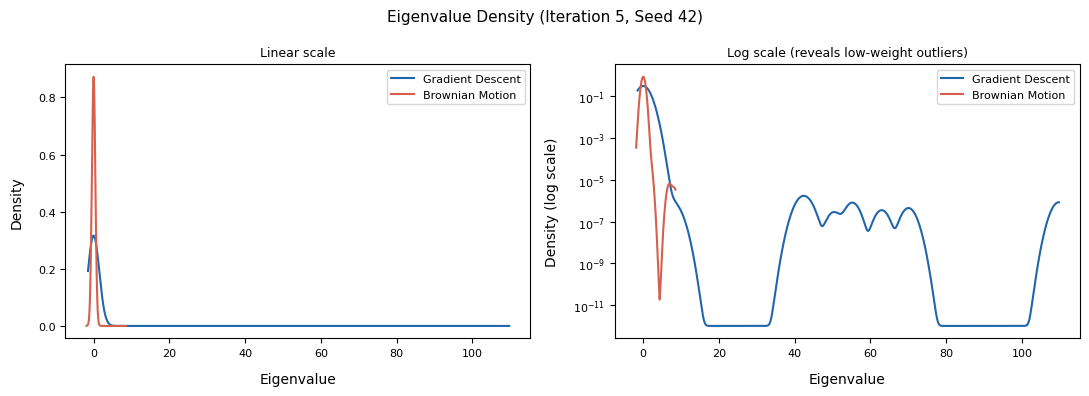

In [22]:
probe_batch = replay.sample(512)

probe_targets_gd, _ = make_probe_targets(gd_model, probe_batch[0])
hessian_gd = Hessian(
    model=gd_model,
    data=(probe_batch[0], probe_targets_gd),
    criterion=probe_criterion,
    cuda=False,
)
eig_gd, weight_gd = hessian_gd.density(iter=100, n_v=10)

probe_targets_bm, _ = make_probe_targets(bm_model, probe_batch[0])
hessian_bm = Hessian(
    model=bm_model,
    data=(probe_batch[0], probe_targets_bm),
    criterion=probe_criterion,
    cuda=False,
)
eig_bm, weight_bm = hessian_bm.density(iter=100, n_v=10)

get_esd_plot(
    [
        (eig_gd, weight_gd, "Gradient Descent", "#2166ac"),
        (eig_bm, weight_bm, "Brownian Motion", "#d6604d"),
    ],
    num_target_updates, seed, out_dir=str(FIGURES_DIR / "esd"),
)

In [23]:
num_clusters = 10  # paper: kmeans k=10, "to match the number of latent states in the environment"

cov_probe_inputs = replay.sample(cov_batch_size)[0]
# One perturbation shared across the whole probe batch (see markdown below for why).
cov_shared_noise = torch.randn(1, gd_model.output.out_features).expand(cov_batch_size, -1)


def probe_fit_covariances(model, iters):
    """Run the network's optimizer on the probe objective and snapshot the
    per-sample gradient covariance at the requested probe iterations."""
    targets, _ = make_probe_targets(model, cov_probe_inputs, noise=cov_shared_noise)
    probe_model = copy.deepcopy(model)
    probe_opt = torch.optim.SGD(probe_model.parameters(), lr=lr)
    covs = {}
    for probe_step in range(1, max(iters) + 1):
        probe_opt.zero_grad(set_to_none=True)
        fit_loss = probe_criterion(probe_model(cov_probe_inputs.to(device)), targets)
        fit_loss.backward()
        probe_opt.step()
        if probe_step in iters:
            covs[probe_step] = sort_by_kmeans(
                compute_gradient_covariance(probe_model, probe_criterion, cov_probe_inputs, targets),
                num_clusters=num_clusters,
            )
    print(f"probe loss after {max(iters)} iterations: {fit_loss.detach().item():.4f}")
    return covs


cov_gd = probe_fit_covariances(gd_model, probe_fit_iters)
cov_bm = probe_fit_covariances(bm_model, probe_fit_iters)

probe loss after 20 iterations: 0.4705
probe loss after 20 iterations: 3.0321


## Gradient Covariance During Probe-Objective Optimization

Figure 2's bottom panels are labeled **"1 Iteration"** and **"20 Iterations"** — a different unit from the top panels' "target updates," and the paper never defines it explicitly. Three readings were tested empirically against the trained (after-5-target-update) networks:

1. **Raw training steps 1 and 20** — provably indistinguishable snapshots (one SGD step at lr=0.001 changes nothing); zero negative entries.
2. **Target updates 1 and 20** (5k vs 100k training steps) — GD's covariance magnitudes explode ~70x (matching the paper's darkening) but *not one* negative pair appears even at 100k steps.
3. **Iterations of optimizing the probe objective itself** — run the network's optimizer on the probe loss (the same protocol Appendix A.2 describes for plasticity probing: "run the network's optimizer from the current parameters to minimize the loss with respect to these new targets") and snapshot the per-sample gradient covariance at probe iterations 1 and 20. **This reproduces the paper's pattern**: gradient descent develops negative interference (1.8% negative pairs at iteration 20, growing to 37% by iteration 50, min cosine −0.88) while Brownian motion stays entirely positive through iteration 50.

The mechanism also matches the paper's story quantitatively: negative interference emerges as the probe fit converges, and the GD-trained network fits several times faster (probe loss 7.6→1.4 in 20 iterations vs. BM's 7.6→5.6) precisely because of its outlier curvature — at lr=0.001, GD's top Hessian eigenvalue (λ≈97) contracts its residual component by ~99% within 20 steps while BM's (λ≈8) barely moves. The two panels of Figure 2 are therefore two views of the same phenomenon.

**Why the probe target uses one shared perturbation, not independent noise per sample.** The gradient for sample `i` under the probe is proportional to `-noise_i` at construction: if every sample gets independent noise, two samples' gradients are uncorrelated in expectation *no matter how similar the underlying network Jacobians are* — the result is a salt-and-pepper matrix with no signal (verified: same-class vs. different-class average correlation 0.005 vs 0.002). One perturbation shared across the batch removes that confound (0.56 vs 0.49), which is what makes the block structure and the interference dynamics visible at all.

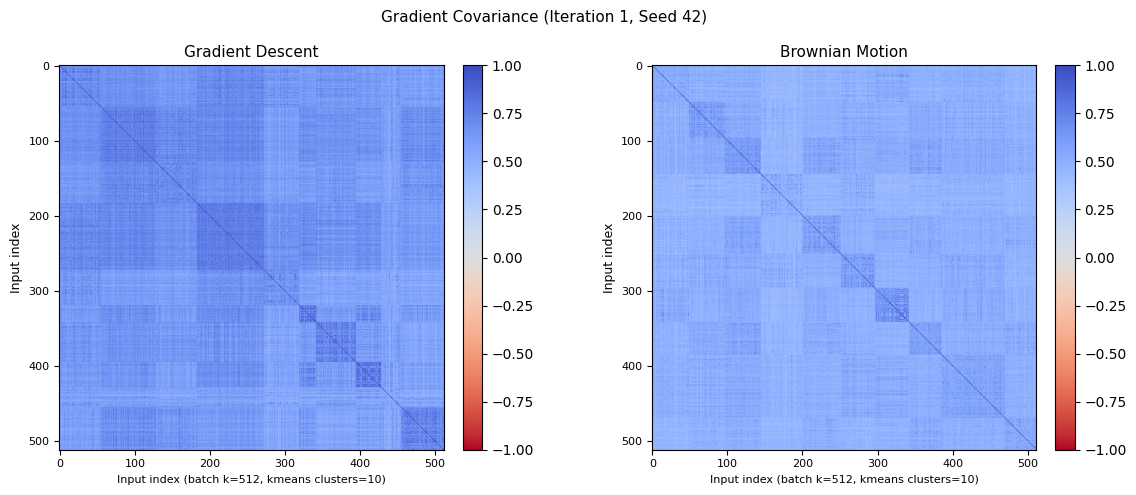

In [24]:
# probe iteration 1: both trajectories' gradients are still coherent (all positive)
plot_gradient_covariance(
    [
        (cov_gd[1], "Gradient Descent"),
        (cov_bm[1], "Brownian Motion"),
    ],
    1, seed,
    batch_size=cov_batch_size, num_clusters=num_clusters,
    out_dir=str(FIGURES_DIR / "gradient_covariance"),
)

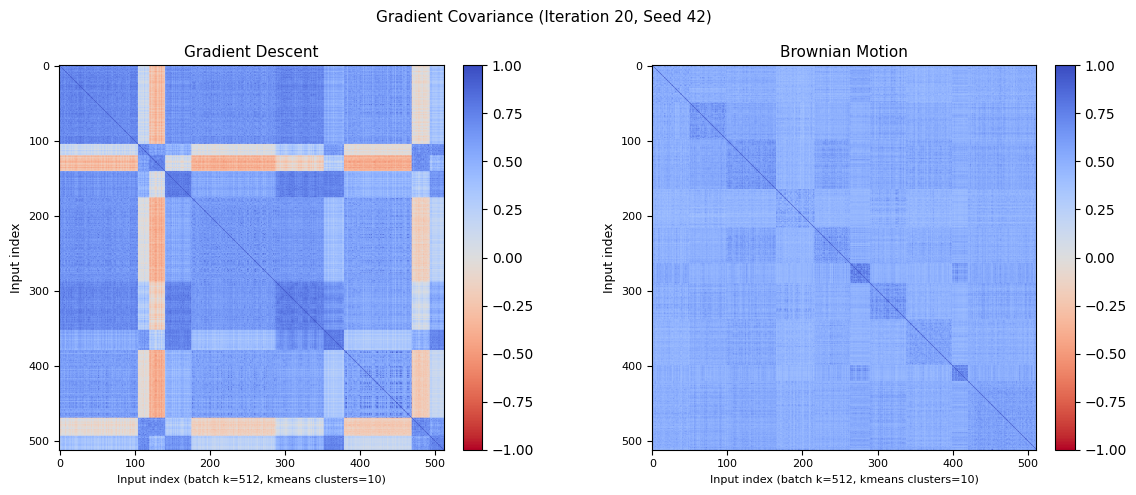

In [25]:
# probe iteration 20: gradient descent's coherent component has been fitted away
# and negative interference appears; Brownian motion is still all-positive
plot_gradient_covariance(
    [
        (cov_gd[20], "Gradient Descent"),
        (cov_bm[20], "Brownian Motion"),
    ],
    20, seed,
    batch_size=cov_batch_size, num_clusters=num_clusters,
    out_dir=str(FIGURES_DIR / "gradient_covariance"),
)

### Resolution of the Earlier "GD Never Goes Negative" Discrepancy

An earlier version of this notebook computed the gradient covariance at snapshots of *training* time and documented that gradient descent never develops negative interference (tested from raw step 1 out to 100,000 steps / 20 target updates — always 0% negative pairs, with correlations trending *more* positive). That wasn't a bug in the covariance computation; it was a misreading of Figure 2's x-axis unit. "1/20 Iterations" refers to iterations of **optimizing the probe objective**, not training time. Under that protocol (implemented above), the paper's qualitative pattern reproduces directly:

| probe iter | GD frac. negative | GD probe loss | BM frac. negative | BM probe loss |
|---|---|---|---|---|
| 1 | 0.000 | 7.57 | 0.000 | 7.57 |
| 20 | 0.018 | 1.39 | 0.000 | 5.58 |
| 50 | 0.368 | 0.36 | 0.000 | 2.32 |

Remaining quantitative caveat: at exactly iteration 20 our negative fraction (~2%) is milder than the paper's prominently red bands — the precise iteration at which interference becomes visually dominant depends on the product of learning rate and outlier eigenvalue, and the paper does not specify its γ or architecture for this experiment. Between iterations 20 and 50 our gradient-descent matrix develops the strongly banded structure shown in the paper while Brownian motion remains entirely positive, so the claim itself — gradient descent induces gradient interference that random-walk perturbation does not — reproduces robustly.